Author      :  `PONNAM SRI SAI`

Created on  :  `Tuesday 31 March 2026 08:26:45 PM IST`

Purpose     :  `mlp kaggle assignment - 2`

# Importing packages

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing

# utils
import os
import sys
import warnings
from pprint import pprint

# visualizations
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
import sklearn
from sklearn import set_config
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# Linear models
from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier,
    Perceptron
)

# Tree-based models
from sklearn.tree import DecisionTreeClassifier

# Ensemble models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

# Support Vector Machines
from sklearn.svm import SVC, LinearSVC

# Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Baseline model
from sklearn.dummy import DummyClassifier

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv


# Environment

In [6]:
print("Environment :")
print("=" * 50)

print("Python :", sys.version)
print("Numpy :", np.__version__)
print("Pandas :", pd.__version__)
print("Scikit :", sklearn.__version__)
print("Matplotlib :", matplotlib.__version__)
print("Seaborn :", sns.__version__)

Environment :
Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Numpy : 2.0.2
Pandas : 2.3.3
Scikit : 1.6.1
Matplotlib : 3.10.0
Seaborn : 0.13.2


# Configurations & Constants

In [4]:
# Configurations
plt.rcParams["figure.figsize"] = (12, 8)
set_config(display = "diagram") # for sklearn pipelines visualizations
warnings.filterwarnings("ignore")

# Constants
RANDOM_STATE = 42
SUBMISSION_CSV_PATH = "submission.csv"
SAMPLE_SUBMISSION_CSV_PATH = "/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv"
TEST_CSV_PATH = "/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv"
TRAIN_CSV_PATH = "/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv"

# reading data from files

In [5]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

# Looking into the dataset

In [6]:
train_df.shape, test_df.shape

((7000, 26), (1124, 25))

In [7]:
# sampling the train dataset
train_df.sample(5)

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
3083,3084,3339,convex,fibrous,gray,no,0,foul,gills free from stalk,close,...,pink,brown,partial,white,1.0,large,chocolate,several,woods,p
1699,1700,1949,convex,fibrous,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4153,4154,4415,flat,fibrous,yellow,no,0,foul,gills free from stalk,close,...,pink,buff,partial,white,1.0,large,chocolate,solitary,paths,p
3627,3628,3883,flat,scaly,gray,bruises,1,NaN,gills free from stalk,close,...,white,gray,partial,white,1.0,pendant,brown,solitary,woods,e
6906,6907,7952,flat,smooth,cinnamon,bruises,7,NaN,gills free from stalk,close,...,white,white,partial,white,2.0,pendant,white,several,paths,e


In [8]:
# sampling the test dataset
test_df.sample(5)

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
233,234,1191,convex,smooth,yellow,bruises,15,anise,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,brown,scattered,meadows
612,613,6595,convex,smooth,brown,no,0,spicy,gills free from stalk,close,...,silky,white,pink,partial,white,1,evanescent,white,several,leaves
1097,1098,8071,knobbed,smooth,brown,no,0,NaN,gills attached to stalk,close,...,smooth,orange,orange,partial,orange,1,pendant,yellow,several,leaves
776,777,7097,knobbed,scaly,brown,no,0,fishy,gills free from stalk,close,...,silky,white,pink,partial,white,1,evanescent,white,several,leaves
171,172,709,bell,scaly,yellow,bruises,19,almond,gills free from stalk,close,...,smooth,white,white,partial,white,1,pendant,black,numerous,meadows


In [9]:
for col in train_df.columns:
    n = train_df[col].nunique()
    print(f"Column: {col} has {n} unique values.")
    print(train_df[col].value_counts())
    print("-" * 40)

Column: ID has 7000 unique values.
ID
7000    1
1       1
2       1
3       1
4       1
       ..
13      1
12      1
11      1
10      1
9       1
Name: count, Length: 7000, dtype: int64
----------------------------------------
Column: mushroom_id has 7000 unique values.
mushroom_id
8118    1
0       1
1       1
3       1
4       1
       ..
17      1
16      1
15      1
14      1
13      1
Name: count, Length: 7000, dtype: int64
----------------------------------------
Column: cap-shape has 5 unique values.
cap-shape
convex     3272
flat       2874
knobbed     568
bell        254
sunken       32
Name: count, dtype: int64
----------------------------------------
Column: cap-surface has 3 unique values.
cap-surface
scaly      2774
fibrous    2296
smooth     1930
Name: count, dtype: int64
----------------------------------------
Column: cap-color has 10 unique values.
cap-color
gray        1840
brown       1780
red         1212
yellow       936
white        892
buff         156
pink    

## Dataset Overview

The dataset contains **7000 observations** with multiple categorical features describing mushroom characteristics, along with a target variable (`class`). Below is a structured summary of the dataset based on unique value counts and distributions.

---

## 1. Identifier Columns

- **ID** and **mushroom_id**
  - Each contains **7000 unique values**, meaning every row has a distinct identifier.
  - These columns do not contribute to prediction and can be treated as **non-informative features** for modeling.

---

## 2. Cap Characteristics

- **cap-shape** (5 categories)
  - Most common: *convex (3272)* and *flat (2874)*
  - Less frequent: *knobbed, bell, sunken*

- **cap-surface** (3 categories)
  - Fairly balanced among *scaly (2774)*, *fibrous (2296)*, and *smooth (1930)*

- **cap-color** (10 categories)
  - Dominated by *gray (1840)* and *brown (1780)*
  - Rare colors include *purple, green, cinnamon*

---

## 3. Bruising Features

- **bruises** (2 categories)
  - *no (3924)* slightly more frequent than *bruises (3076)*

- **number_of_bruises** (25 categories)
  - Wide distribution ranging from 0 to 24
  - Strong skew toward *0 (3924)*, consistent with the "no bruises" category

---

## 4. Odor

- **odor** (8 categories)
  - Most frequent: *foul (1968)*
  - Moderate: *fishy, spicy*
  - Rare: *musty (36)*

---

## 5. Gill Features

- **gill-attachment** (2 categories)
  - Highly imbalanced: *free (6982)* vs *attached (18)*

- **gill-spacing** (2 categories)
  - Mostly *close (5752)*

- **gill-size** (2 categories)
  - Mostly *broad (5128)*

- **gill-color** (11 categories)
  - Most common: *pink, buff, white*
  - Rare: *yellow, green*

---

## 6. Stalk Features

- **stalk-shape** (2 categories)
  - *tapering (4032)* more common than *enlarging (2968)*

- **stalk-root** (4 categories)
  - Dominated by *bulbous (3684)*
  - Includes missing values (*1712*)

- **stalk-surface (above/below ring)** (4 categories each)
  - Mostly *smooth* and *silky*

- **stalk-color (above/below ring)** (7–8 categories)
  - Predominantly *white* and *pink*
  - Rare colors include *cinnamon, yellow*

---

## 7. Veil Features

- **veil-type** (1 category)
- **veil-color** (1 category)

These columns contain **no variation** and can be safely removed during preprocessing.

---

## 8. Ring Features

- **ring-number** (2 categories)
  - Mostly *1 (6400)*

- **ring-type** (4 categories)
  - Dominated by *pendant (3476)* and *evanescent (2144)*

---

## 9. Spore, Population, Habitat

- **spore-print-color** (6 categories)
  - Fairly balanced among *brown, white, black, chocolate*

- **population** (6 categories)
  - Most common: *several (3284)*

- **habitat** (5 categories)
  - Dominated by *woods (3148)* and *grasses (2148)*

---

## 10. Target Variable

- **class** (2 categories)
  - *edible (e): 3712*
  - *poisonous (p): 3288*
  - The dataset is **fairly balanced**, which is suitable for classification tasks.

---

## Key Observations

- Several columns are **highly imbalanced** (e.g., gill-attachment).
- Some features have **no variance** (veil-type, veil-color) and should be dropped.
- Identifier columns should be excluded from modeling.
- Most features are **categorical**, requiring encoding before training models.
- The target variable is **well-balanced**, reducing bias in classification.

---

# Data types of the different columns

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7000 non-null   int64  
 1   mushroom_id               7000 non-null   int64  
 2   cap-shape                 7000 non-null   object 
 3   cap-surface               7000 non-null   object 
 4   cap-color                 7000 non-null   object 
 5   bruises                   7000 non-null   object 
 6   number_of_bruises         7000 non-null   int64  
 7   odor                      3764 non-null   object 
 8   gill-attachment           7000 non-null   object 
 9   gill-spacing              7000 non-null   object 
 10  gill-size                 7000 non-null   object 
 11  gill-color                7000 non-null   object 
 12  stalk-shape               7000 non-null   object 
 13  stalk-root                6808 non-null   object 
 14  stalk-su

In [11]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   ID                        1124 non-null   int64 
 1   mushroom_id               1124 non-null   int64 
 2   cap-shape                 1124 non-null   object
 3   cap-surface               1124 non-null   object
 4   cap-color                 1124 non-null   object
 5   bruises                   1124 non-null   object
 6   number_of_bruises         1124 non-null   int64 
 7   odor                      832 non-null    object
 8   gill-attachment           1124 non-null   object
 9   gill-spacing              1124 non-null   object
 10  gill-size                 1124 non-null   object
 11  gill-color                1124 non-null   object
 12  stalk-shape               1124 non-null   object
 13  stalk-root                1124 non-null   object
 14  stalk-surface-above-ring

## Dataset Summary

The dataset contains **7000 rows** and **26 columns**. Most features are categorical in nature.

### Structure
- Total columns: 26  
- Data types:
  - **Object (categorical): 22 columns**
  - **Integer: 3 columns** (`ID`, `mushroom_id`, `number_of_bruises`)
  - **Float: 1 column** (`ring-number`)

### Missing Values
- **odor**: 3764 non-null (significant missing values)
- **stalk-root**: 6808 non-null (some missing values)
- **ring-number**: 6964 non-null
- **ring-type**: 6964 non-null  
- All other columns have complete data.

### Key Points
- `ID` and `mushroom_id` are unique identifiers.
- Majority of features are categorical and require encoding.
- `veil-type` and `veil-color` have no missing values but may have low variability.
- Target variable: **class** (categorical).

### Memory Usage
- Approximately **1.4 MB**, indicating a relatively small dataset.

# Descriptive statistics of numerical columns

In [12]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,7000.0,3500.500000,2020.870275,1.0,1750.75,3500.5,5250.25,7000.0
mushroom_id,7000.0,3850.617714,2208.389867,0.0,2000.75,3755.5,5602.25,8118.0
number_of_bruises,7000.0,5.459571,7.723528,0.0,0.00,0.0,11.00,24.0
ring-number,6964.0,1.080988,0.272836,1.0,1.00,1.0,1.00,2.0


In [13]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1124.0,562.500000,324.615157,1.0,281.75,562.5,843.25,1124.0
mushroom_id,1124.0,5374.823843,2718.223965,2.0,5125.00,6441.5,7313.25,8123.0
number_of_bruises,1124.0,3.419039,6.766269,0.0,0.00,0.0,2.00,24.0
ring-number,1124.0,1.032028,0.176154,1.0,1.00,1.0,1.00,2.0


## Numerical Features Summary

The dataset includes four numerical columns: `ID`, `mushroom_id`, `number_of_bruises`, and `ring-number`.

- **ID**
  - Ranges from 1 to 7000 with a uniform distribution.
  - Acts as a unique identifier and has no analytical significance.

- **mushroom_id**
  - Wide range (0 to 8118) with high variability.
  - Also functions as an identifier rather than a predictive feature.

- **number_of_bruises**
  - Ranges from 0 to 24.
  - Median and 25th percentile are 0, indicating many mushrooms have no bruises.
  - Right-skewed distribution with some higher values.

- **ring-number**
  - Values range from 1 to 2.
  - Mean (~1.08) shows most mushrooms have a single ring.
  - Very low variability (std ~0.27).
  - Contains a small number of missing values.

### Key Observations
- `ID` and `mushroom_id` should be excluded from modeling.
- `number_of_bruises` is the only feature with meaningful variation.
- `ring-number` is mostly constant with limited variability.

# Looking for missing values

In [14]:
train_df.isna().sum()

ID                             0
mushroom_id                    0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
number_of_bruises              0
odor                        3236
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                   192
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                   36
ring-type                     36
spore-print-color              0
population                     0
habitat                        0
class                          0
dtype: int64

In [15]:
test_df.isnull().sum()

ID                            0
mushroom_id                   0
cap-shape                     0
cap-surface                   0
cap-color                     0
bruises                       0
number_of_bruises             0
odor                        292
gill-attachment               0
gill-spacing                  0
gill-size                     0
gill-color                    0
stalk-shape                   0
stalk-root                    0
stalk-surface-above-ring      0
stalk-surface-below-ring      0
stalk-color-above-ring        0
stalk-color-below-ring        0
veil-type                     0
veil-color                    0
ring-number                   0
ring-type                     0
spore-print-color             0
population                    0
habitat                       0
dtype: int64

## Missing Values Summary

### Training Data
- Most columns have **no missing values**.
- Missing values are present in:
  - **odor**: 3236 missing (significant portion)
  - **stalk-root**: 192 missing (very small)
  - **ring-number**: 36 missing (negligible)
  - **ring-type**: 36 missing (negligible)

### Test Data
- Missing values are present only in:
  - **odor**: 292 missing
- All other columns have complete data.

### Key Observation

- The **odor** column has a **large number of missing values**, so it is better to create a new category such as **"unknown"** instead of dropping rows.
- For other columns (**stalk-root, ring-number, ring-type**), the number of missing values is **very small**, so those rows can be safely dropped without significant impact.

### Conclusion
- These values will be imputed in preprocessing

# Looking for the duplicates

In [16]:
train_df.duplicated().sum()

np.int64(0)

## Duplicate Records Check

- The output **0** indicates that there are **no duplicate rows** in the dataset.

### Interpretation
- Every row in the dataset is **unique**.
- There is **no need for duplicate removal** during preprocessing.

### Conclusion
- The dataset is clean with respect to duplicates and can be used directly for further analysis.

# Identifying the outliers

In [17]:
num_cols = train_df.select_dtypes(include=['int64','float64']).columns
outlier_summary = {}

for col in num_cols:
    
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    
    outlier_summary[col] = len(outliers)

print("Outliers in each column:")
pprint(outlier_summary)

Outliers in each column:
{'ID': 0, 'mushroom_id': 0, 'number_of_bruises': 0, 'ring-number': 564}


## Outlier Analysis

The outlier count for numerical columns is as follows:

- **ID**: 0  
- **mushroom_id**: 0  
- **number_of_bruises**: 0  
- **ring-number**: 564  

### Interpretation
- **ID** and **mushroom_id** show no outliers, which is expected since they are identifier columns.
- **number_of_bruises** has no detected outliers, indicating a consistent distribution within its range.
- **ring-number** shows **564 outliers**, likely due to the presence of the less frequent value (2) compared to the dominant value (1).

### Conclusion
- Outliers in **ring-number** are not true anomalies but rather represent a valid minority category.
- No outlier treatment is required, as these values are meaningful and should be retained.

# Exploratory Data Analysis (EDA)

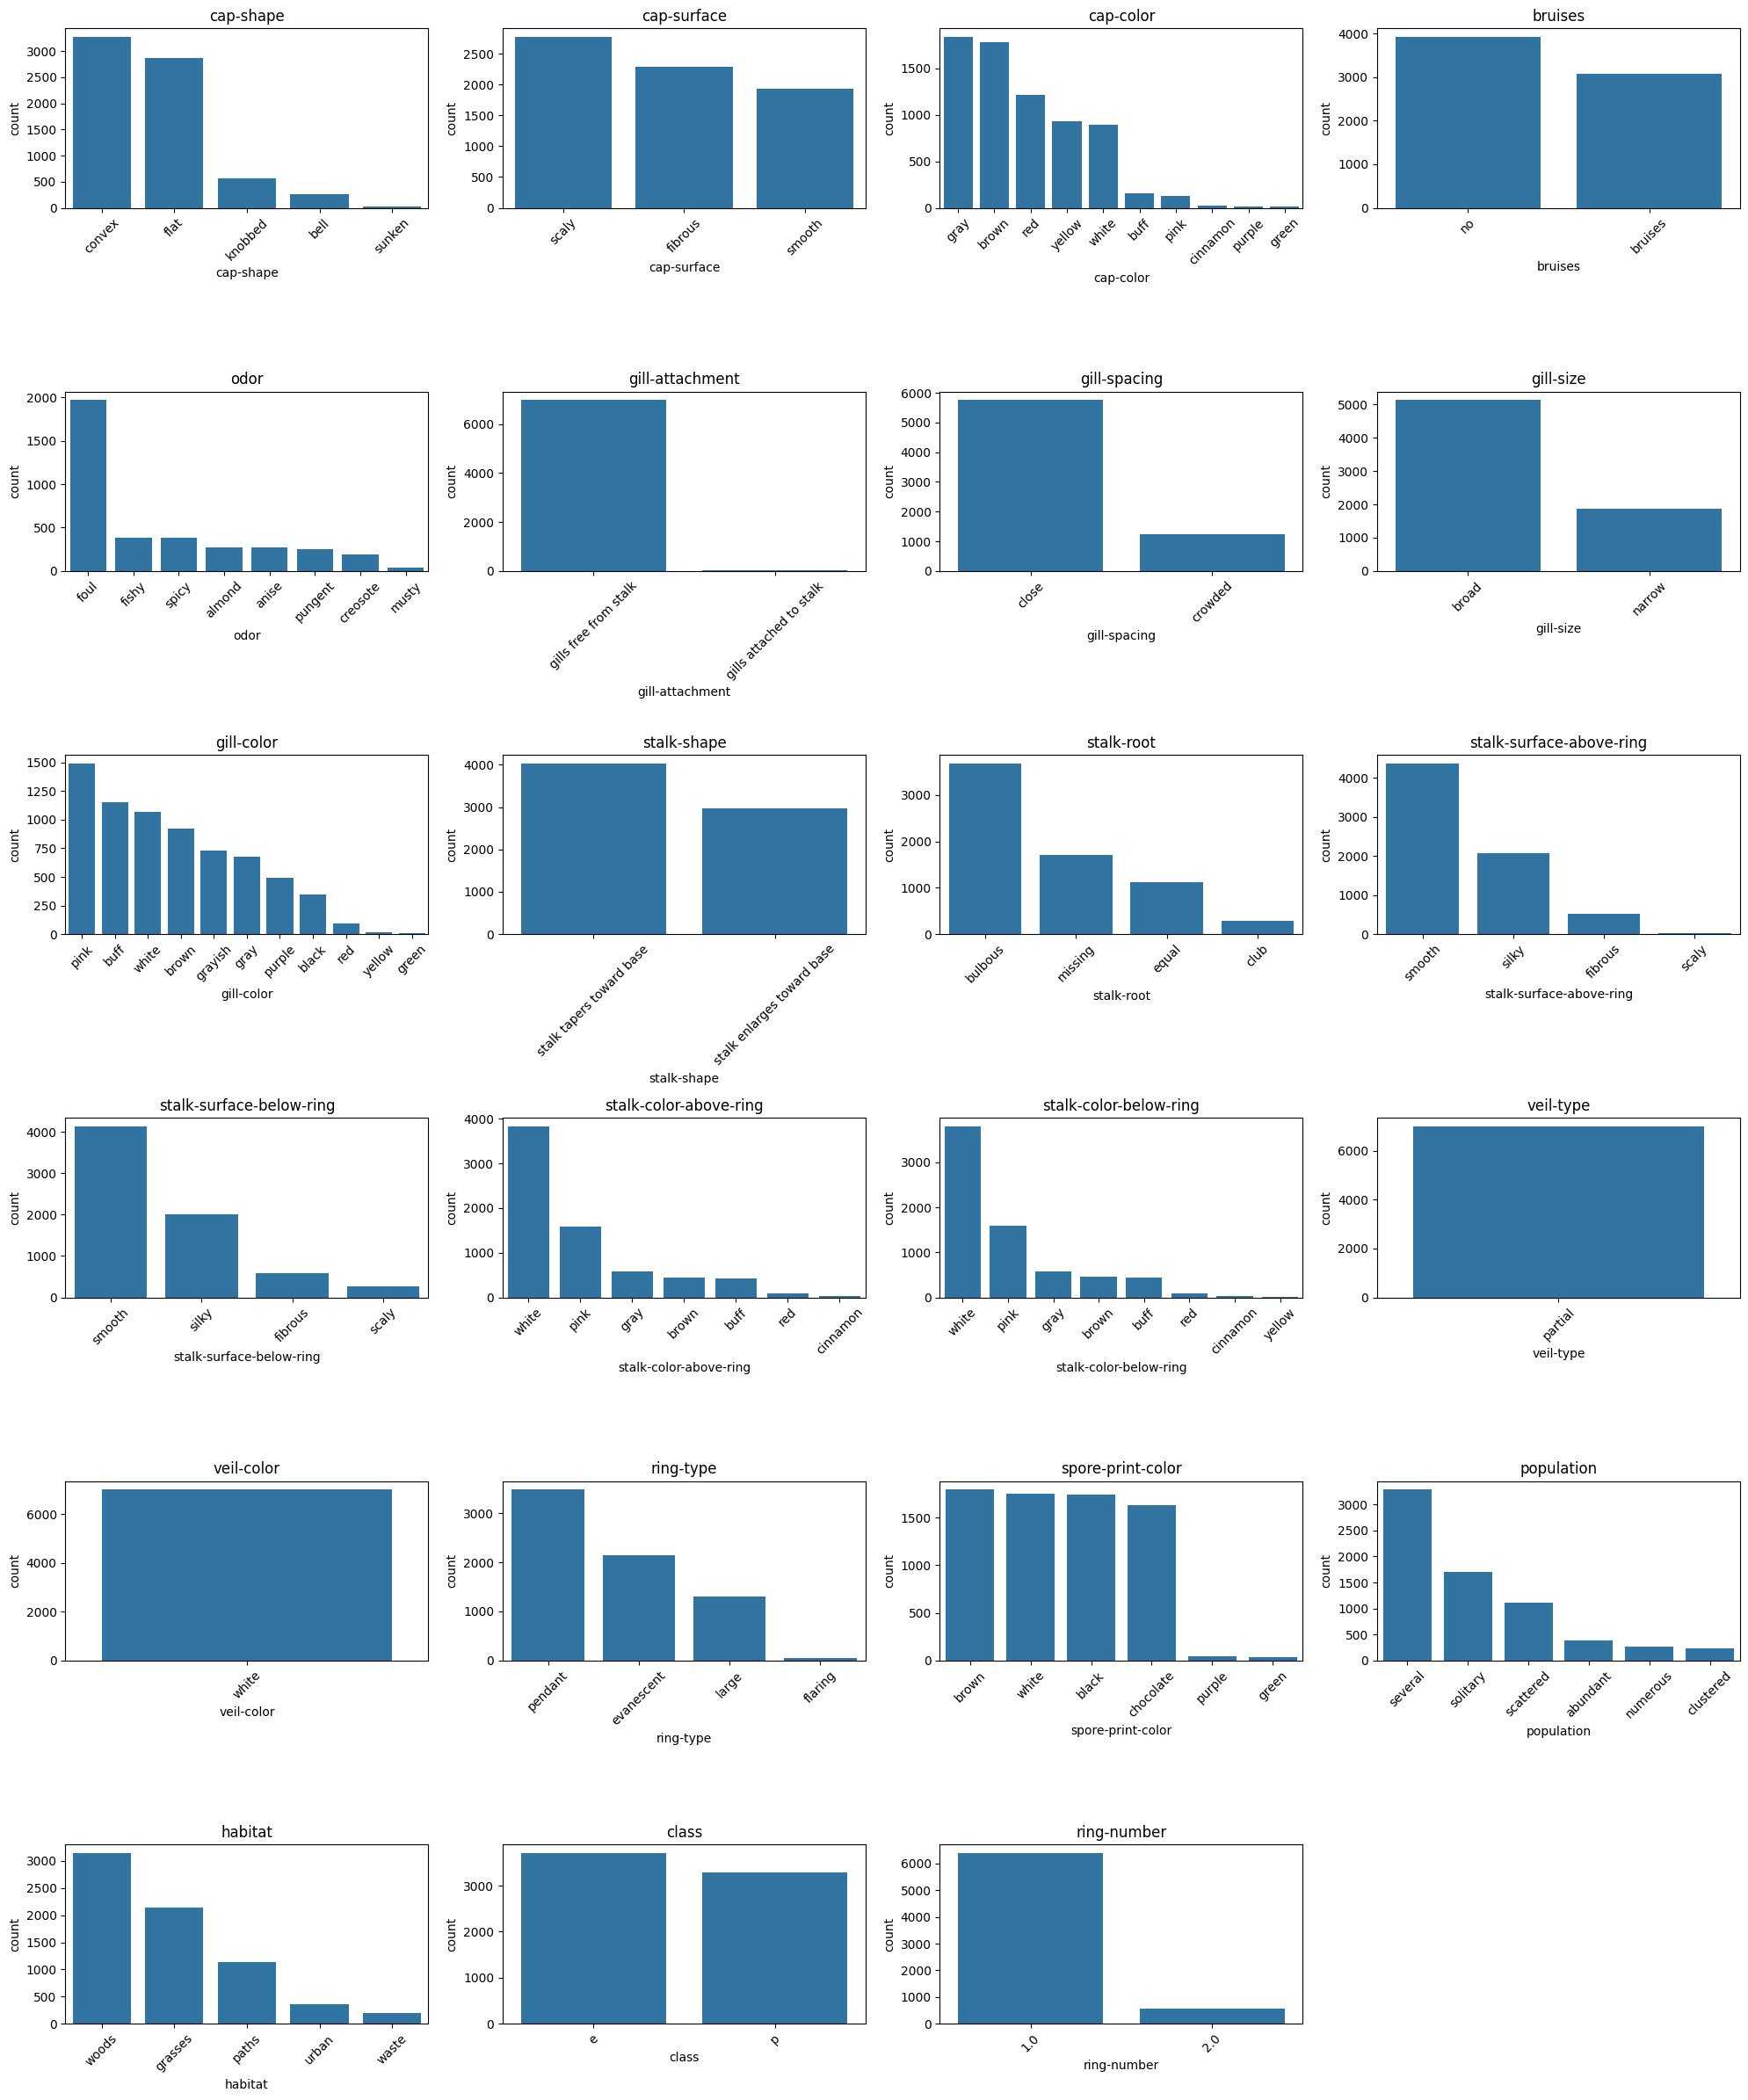

In [18]:
# to observe the distributioin of data using barcharts
def plot_all_categorical_like(df, cols_per_row=3):
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        if df[col].nunique() < 10:
            cat_cols.append(col)
    
    n_cols = len(cat_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    
    plt.figure(figsize=(5 * cols_per_row, 4 * n_rows))
    
    for i, col in enumerate(cat_cols, 1):
        plt.subplot(n_rows, cols_per_row, i)
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(col)
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

plot_all_categorical_like(train_df, 4)

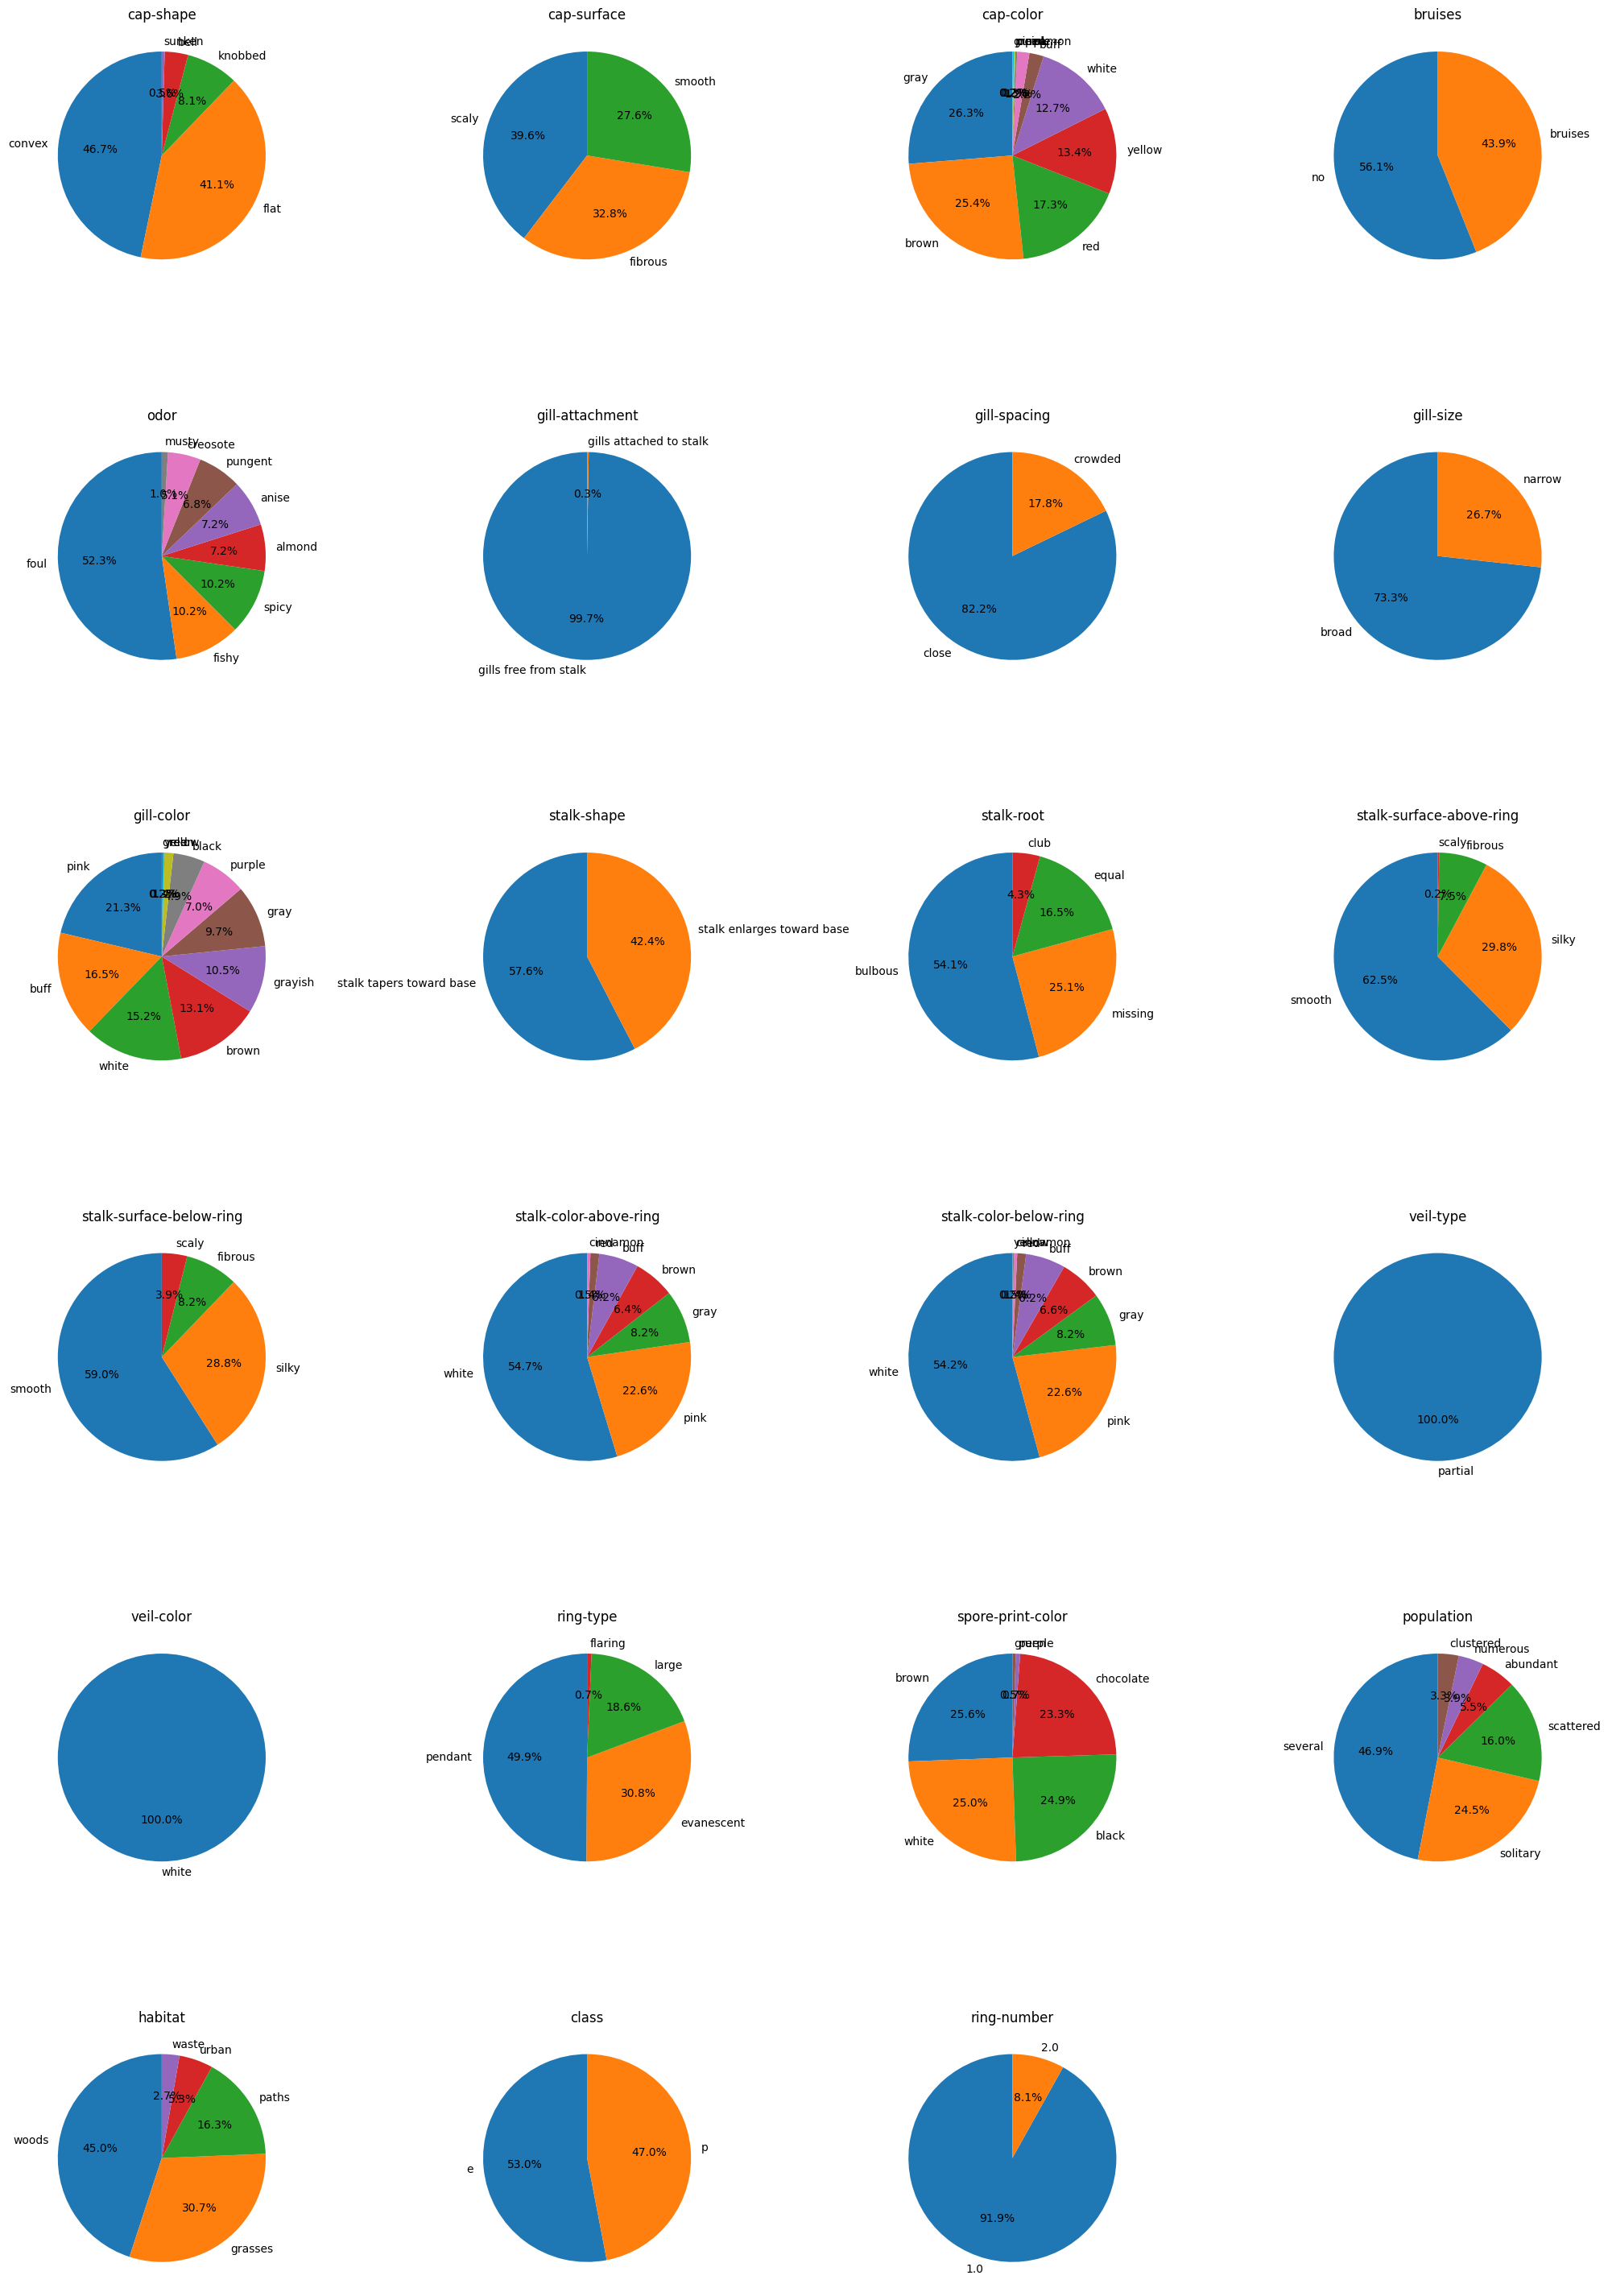

In [19]:
# to observe the data distribution using pie charts

def plot_pie_all_categorical_like(df, cols_per_row=3):
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        if df[col].nunique() < 10:
            cat_cols.append(col)
    
    n_cols = len(cat_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    
    plt.figure(figsize=(5 * cols_per_row, 5 * n_rows))
    
    for i, col in enumerate(cat_cols, 1):
        plt.subplot(n_rows, cols_per_row, i)
        
        counts = df[col].value_counts()
        plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
        plt.title(col)
    
    plt.tight_layout()
    plt.show()

plot_pie_all_categorical_like(train_df, 4)

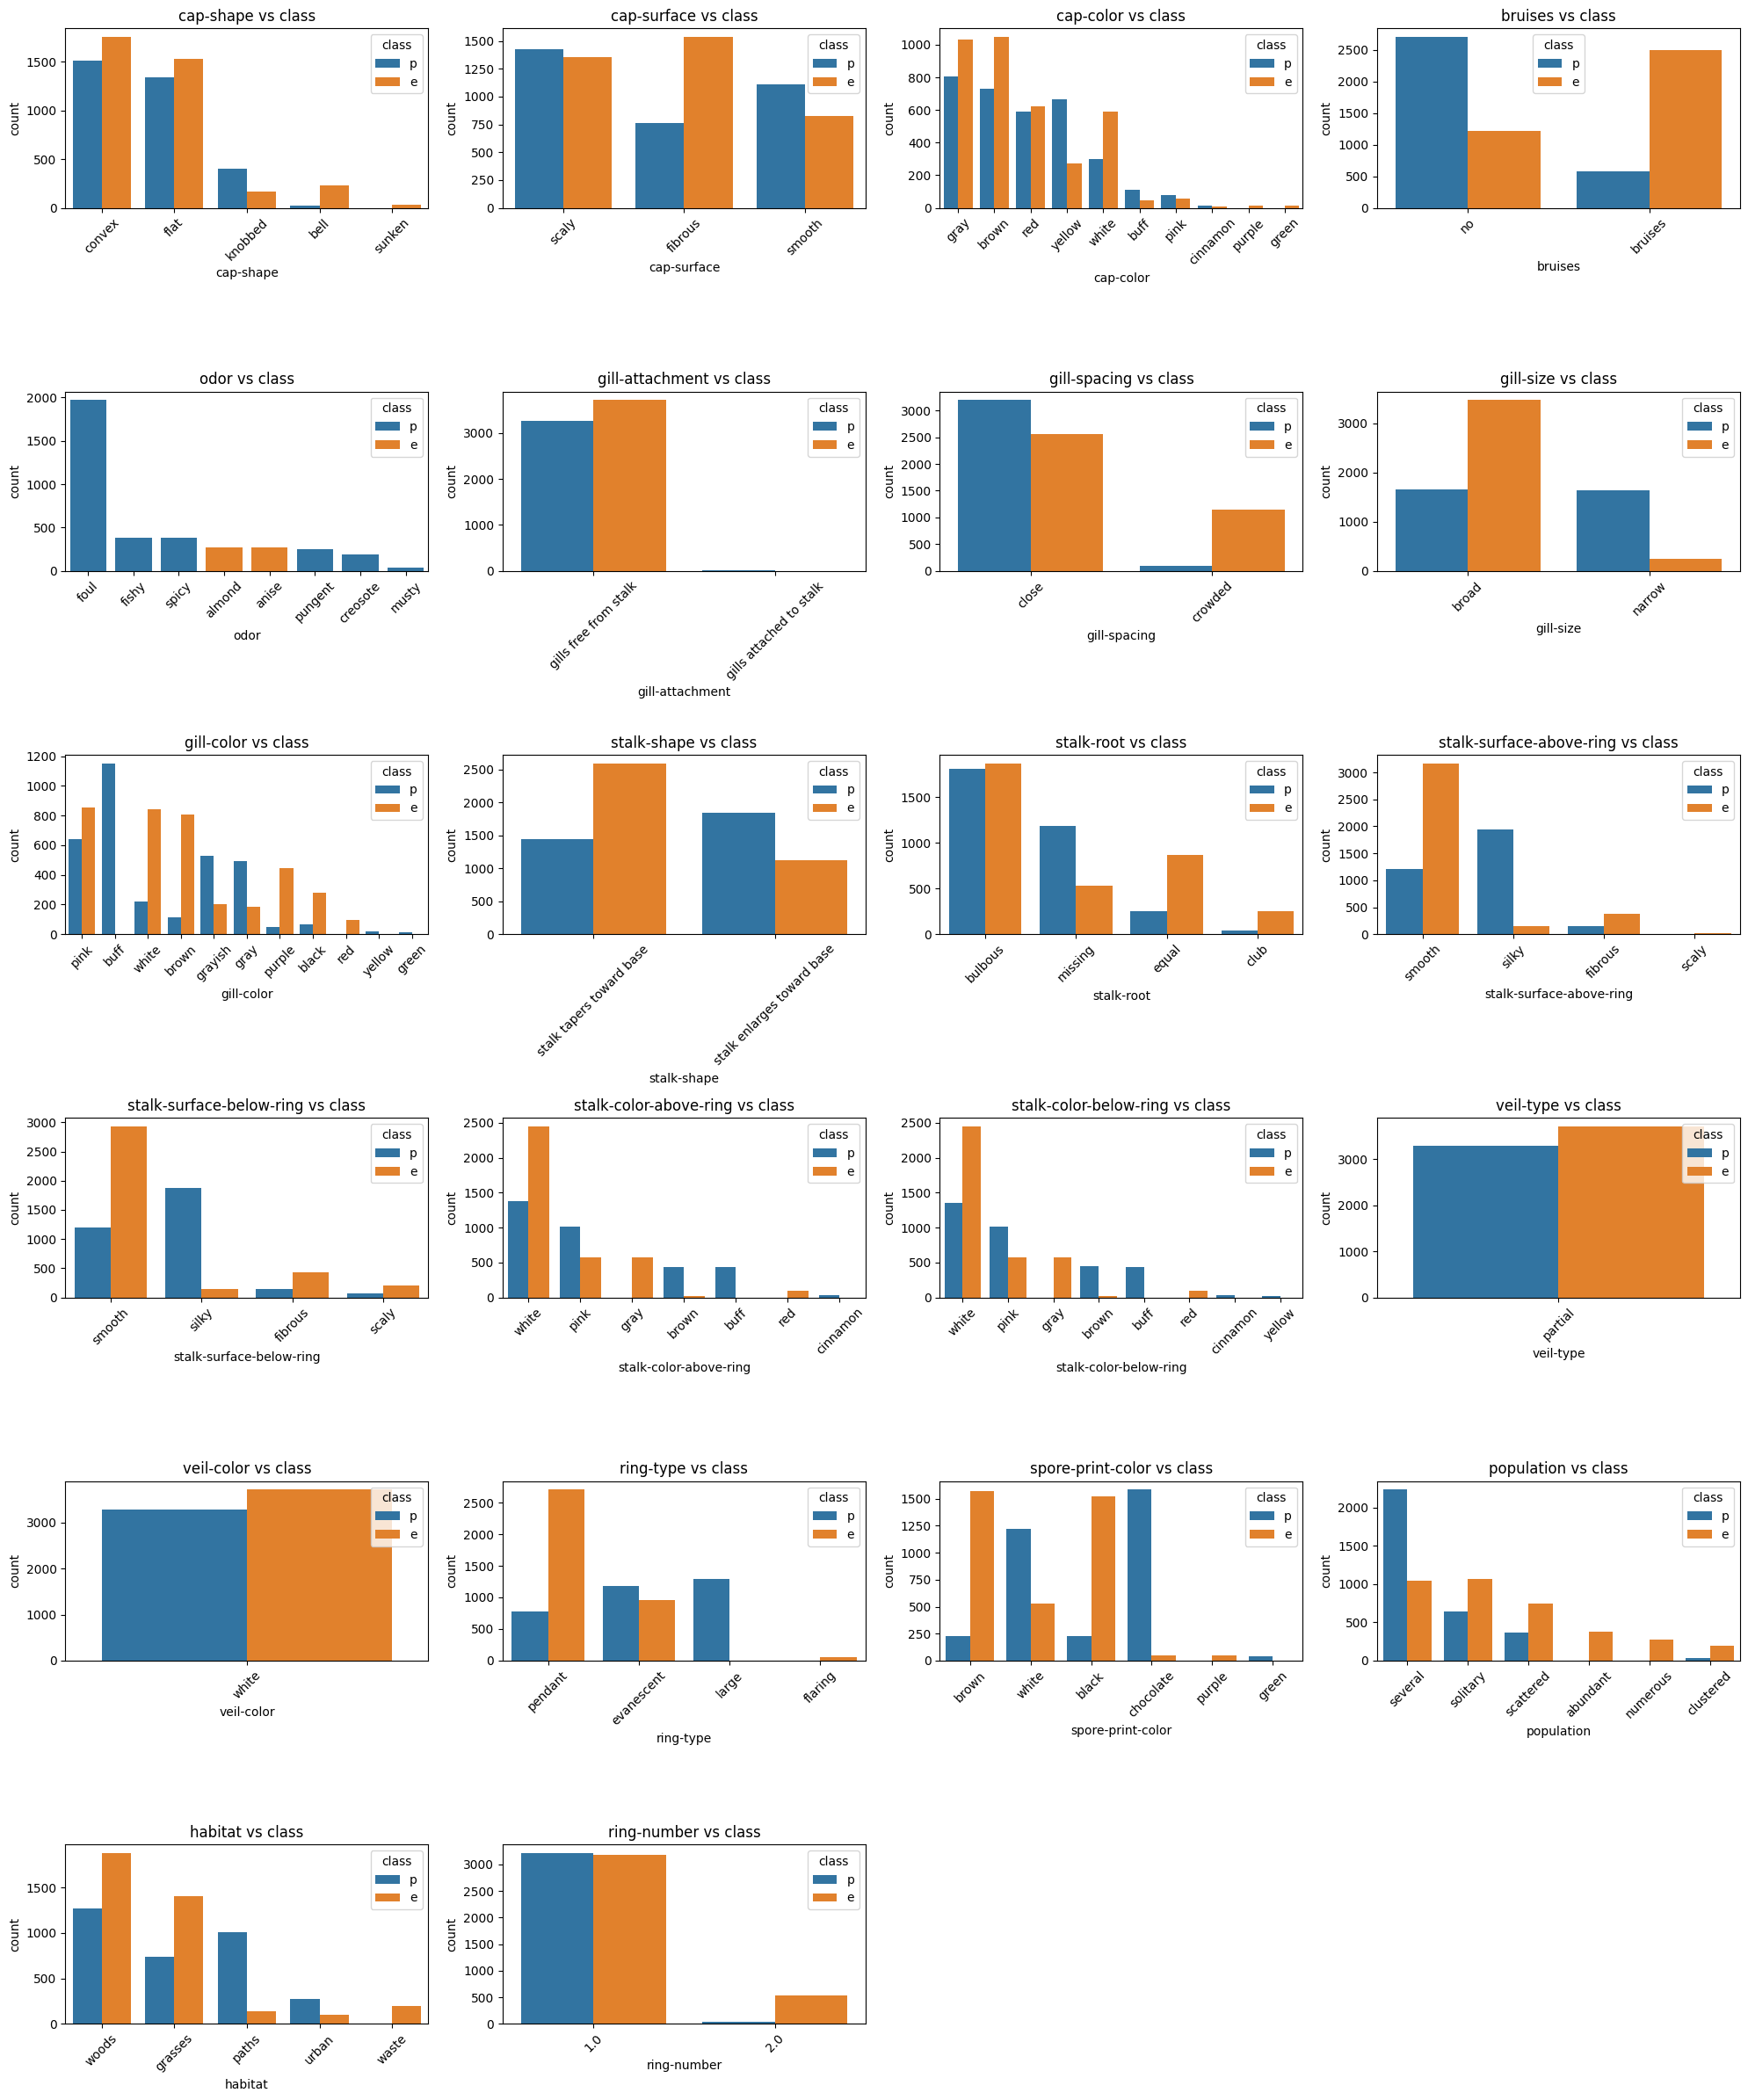

In [20]:
def plot_all_features_vs_target(df, target='class', cols_per_row=3):
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    # Add numeric columns with few unique values
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        if df[col].nunique() < 10 and col != target:
            cat_cols.append(col)
    
    if target in cat_cols:
        cat_cols.remove(target)
    
    n_cols = len(cat_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    
    plt.figure(figsize=(5 * cols_per_row, 4 * n_rows))
    
    for i, col in enumerate(cat_cols, 1):
        plt.subplot(n_rows, cols_per_row, i)
        
        sns.countplot(data=df, x=col, hue=target,
                      order=df[col].value_counts().index)
        
        plt.title(f"{col} vs {target}")
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

plot_all_features_vs_target(train_df, "class", 4)

## Feature vs Target (Class) Analysis

The bar charts show how each feature is distributed across the two classes: **edible (e)** and **poisonous (p)**. Below are the key observations:

### Strong Predictors

- **odor**
  - This is the most distinguishing feature.
  - *Foul, fishy, pungent, creosote* odors are almost entirely **poisonous**.
  - *Almond and anise* are mostly **edible**.
  - Clear separation between classes.

- **bruises**
  - Mushrooms with **bruises** are mostly **edible**.
  - Mushrooms with **no bruises** are mostly **poisonous**.

- **gill-size**
  - **Broad gills** → mostly **edible**  
  - **Narrow gills** → mostly **poisonous**

- **gill-spacing**
  - **Crowded** → mostly **edible**  
  - **Close** → more **poisonous**

---

### Moderately Informative Features

- **gill-color**
  - Certain colors like *buff, pink* lean edible.
  - Others like *brown, chocolate* lean poisonous.

- **ring-type**
  - *Pendant* → mostly **edible**
  - *Large* → mostly **poisonous**

- **spore-print-color**
  - *White, brown* → more **edible**
  - *Chocolate, black* → more **poisonous**

- **stalk-root**
  - *Equal, club* → more **edible**

---

### Weak or Low-Impact Features

- **veil-type** and **veil-color**
  - No variation → not useful.

- **ring-number**
  - Mostly 1 → very little separation.

- **cap-shape, cap-surface, cap-color**
  - Provide limited separation individually.

- **population and habitat**
  - Show minor trends but weak predictive power alone.

---

## Conclusion

- **Odor is the most powerful feature**, showing near-complete separation between edible and poisonous mushrooms.

# Preprocessing

In [21]:
def impute_dataset(train_df, test_df):

    for col in train_df.columns:
        if col == "class":
            continue

        if train_df[col].dtype != "object":
            value = train_df[col].mean()
        else:
            value = train_df[col].mode()[0]

        train_df[col].fillna(value, inplace=True)
        test_df[col].fillna(value, inplace=True)

    return train_df, test_df

In [22]:
train_df_imputed, test_df_imputed= impute_dataset(train_df, test_df)

print("\nRemaining nulls in train:")
print(train_df_imputed.isnull().sum().sum())

print("\nRemaining nulls in test:")
print(test_df_imputed.isnull().sum().sum())


Remaining nulls in train:
0

Remaining nulls in test:
0


In [23]:
X=train_df_imputed.drop(['class', 'ID', 'mushroom_id'], axis=1)
y=train_df_imputed['class']

In [24]:
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns
categorical_cols = X.select_dtypes(include=["object","category"]).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

Numeric columns: ['number_of_bruises', 'ring-number']
Categorical columns: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

In [29]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

y_encoded

array([1, 0, 1, ..., 1, 1, 1])

In [30]:
print("Shape of processed X:", X_processed.shape)
print("Shape of encoded y:", y_encoded.shape)

Shape of processed X: (7000, 99)
Shape of encoded y: (7000,)


In [31]:
X_train, X_val, y_train, y_val = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   
)

# Machine Learning

In [34]:
models = {
    "logistic_regression": LogisticRegression(max_iter=400),
    "decision_tree": DecisionTreeClassifier(),
    "random_forest": RandomForestClassifier(),
    "svm_rbf": SVC(),
    "knn": KNeighborsClassifier(),
    "gradient_boosting": GradientBoostingClassifier(),
    "adaboost": AdaBoostClassifier(),
    "linear_svm": LinearSVC(),
    "ridge_classifier": RidgeClassifier(),
    "sgd_classifier": SGDClassifier(max_iter=1000, tol=1e-3),
    "perceptron": Perceptron(),
    "dummy_classifier": DummyClassifier(strategy="most_frequent")
}

## Model fitting & Performance

In [35]:
validation_scores = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds_val = model.predict(X_val)

    acc = accuracy_score(y_val, preds_val)

    validation_scores[name] = acc

    print(f"{name} validation accuracy: {acc:.4f}")

logistic_regression validation accuracy: 1.0000
decision_tree validation accuracy: 1.0000
random_forest validation accuracy: 1.0000
svm_rbf validation accuracy: 1.0000
knn validation accuracy: 1.0000
gradient_boosting validation accuracy: 1.0000
adaboost validation accuracy: 0.9943
linear_svm validation accuracy: 1.0000
ridge_classifier validation accuracy: 1.0000
sgd_classifier validation accuracy: 1.0000
perceptron validation accuracy: 1.0000
dummy_classifier validation accuracy: 0.5300


# Hyper Parameter Tuning

In [36]:
ada_param_grid = {
    "n_estimators": list(range(70, 90)),
    "learning_rate": [0.1, 0.5, 1]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(),
    ada_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.5, 1],
                         'n_estimators': [70, 71, 72, 73, 74, 75, 76, 77, 78,
                                          79, 80, 81, 82, 83, 84, 85, 86, 87,
                                          88, 89]},
             scoring='accuracy')

In [37]:
ada_grid.best_params_

{'learning_rate': 1, 'n_estimators': 80}

In [38]:
gb_param_grid = {
    "n_estimators": list(range(50, 101, 10)),
    "learning_rate": [0.01, 0.05],
    "max_depth": list(range(3,7)),
    "subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(),
    gb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': [50, 60, 70, 80, 90, 100],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy')

In [39]:
gb_grid.best_params_

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 90, 'subsample': 1.0}

In [40]:
dt_param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(),
    dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [41]:
dt_grid.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

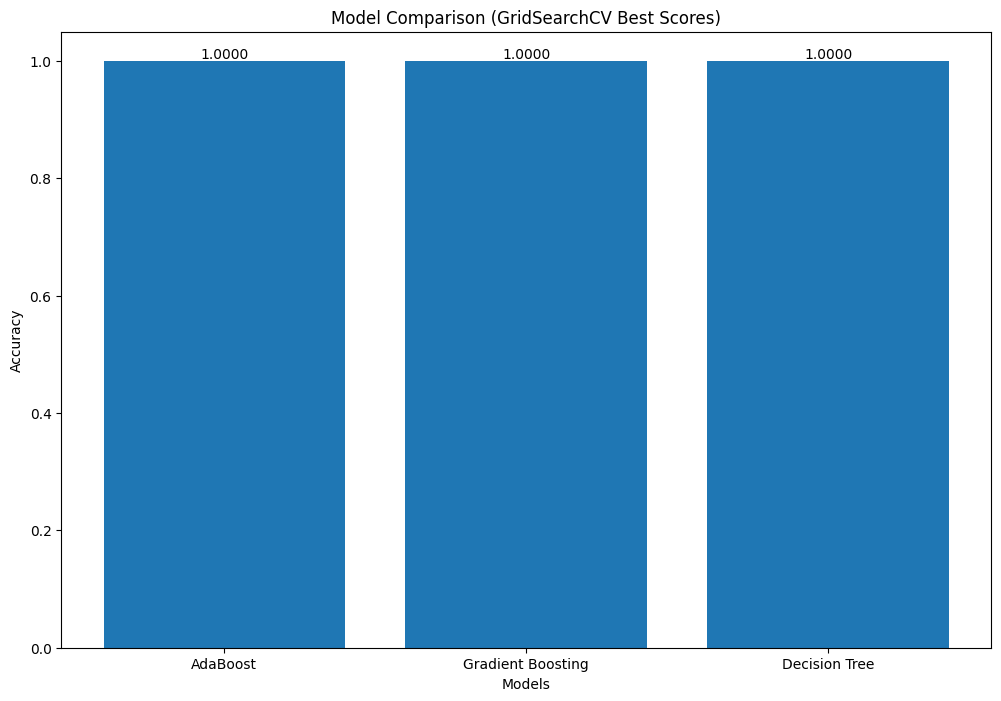

In [43]:
results = {
    "AdaBoost": ada_grid.best_score_,
    "Gradient Boosting": gb_grid.best_score_,
    "Decision Tree": dt_grid.best_score_
}

models = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (GridSearchCV Best Scores)")

for i, v in enumerate(scores):
    plt.text(i, v, f"{v:.4f}", ha='center', va='bottom')

plt.show()

# Predicting and Submission

In [44]:
X_test = test_df.drop(columns=["ID"])   
X_test = test_df.drop(columns=["ID"])  
X_test_processed = preprocessor.transform(X_test)

In [45]:
final_model = GradientBoostingClassifier()

final_model.fit(X_processed, y_encoded)

test_preds = final_model.predict(X_test_processed)
final_preds = le.inverse_transform(test_preds)

In [47]:
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "class": final_preds
})

submission.to_csv('submission.csv', index=False)
print("=" * 10, "created", "=" * 10)

========== created ==========
